In [1]:
import numpy as np
import datetime
import matplotlib.pyplot as plt
import pickle
import pyproj
from pyproj import Proj, transform
import rasterio
from rasterio.plot import show
import matplotlib.colors as colors


In [2]:
roots = "C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\"
file_names = ['dados_gps.pkl', 'dados_ctd.pkl']

# Dicionário para armazenar os dados já processados de velocidadee outros
data = {}

# Loop através dos nomes dos arquivos e carrega os dados usando pickle
for file_name in file_names:
    with open(roots+file_name, 'rb') as file:
        data[file_name.replace('.pkl', '')] = pickle.load(file)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0466925].


(-32.21, -32.15)

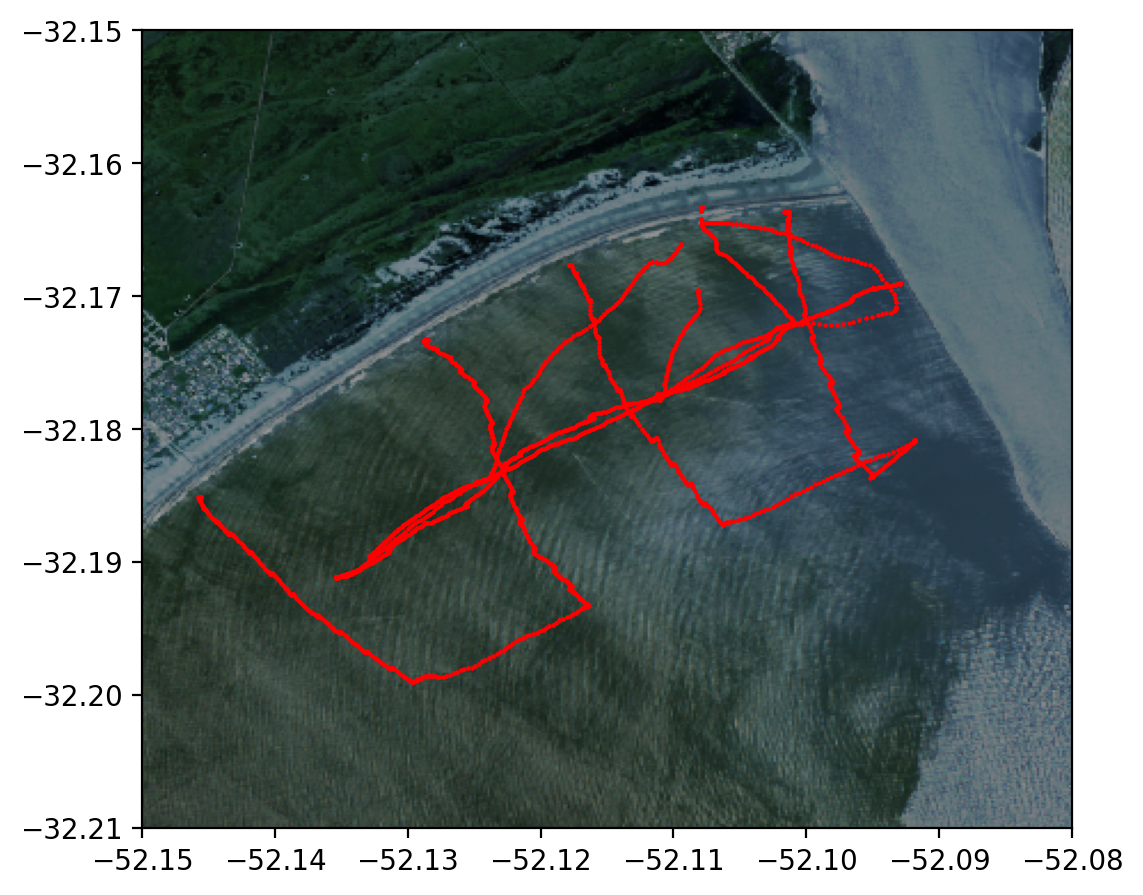

In [3]:
fp ='C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\dados_brutos\\2023-11-23-00_00_2023-11-23-23_59_Sentinel-2_L2A_Highlight_Optimized_Natural_Color.tiff'
img = rasterio.open(fp)
red_band = img.read(3) 
green_band = img.read(2)
blue_band = img.read(1)

# Reorganiza as bandas para RGB
rgb_img = np.stack([red_band, green_band, blue_band], axis=-1)

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Exibir a imagem rasterio
ax.imshow(rgb_img, extent=[img.bounds.left, img.bounds.right, img.bounds.bottom, img.bounds.top])
ax.scatter(data['dados_gps'][:][1], data['dados_gps'][:][2], s=0.5, color ='r')
#ax.set_xlim([-52.15, -52.08])
#ax.set_ylim([-32.21, -32.15])
ax.set_xlim([-52.15, -52.08])
ax.set_ylim([-32.21, -32.15])
#ax.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0466925].


(np.float64(-52.15),
 np.float64(-52.08),
 np.float64(-32.21),
 np.float64(-32.15))

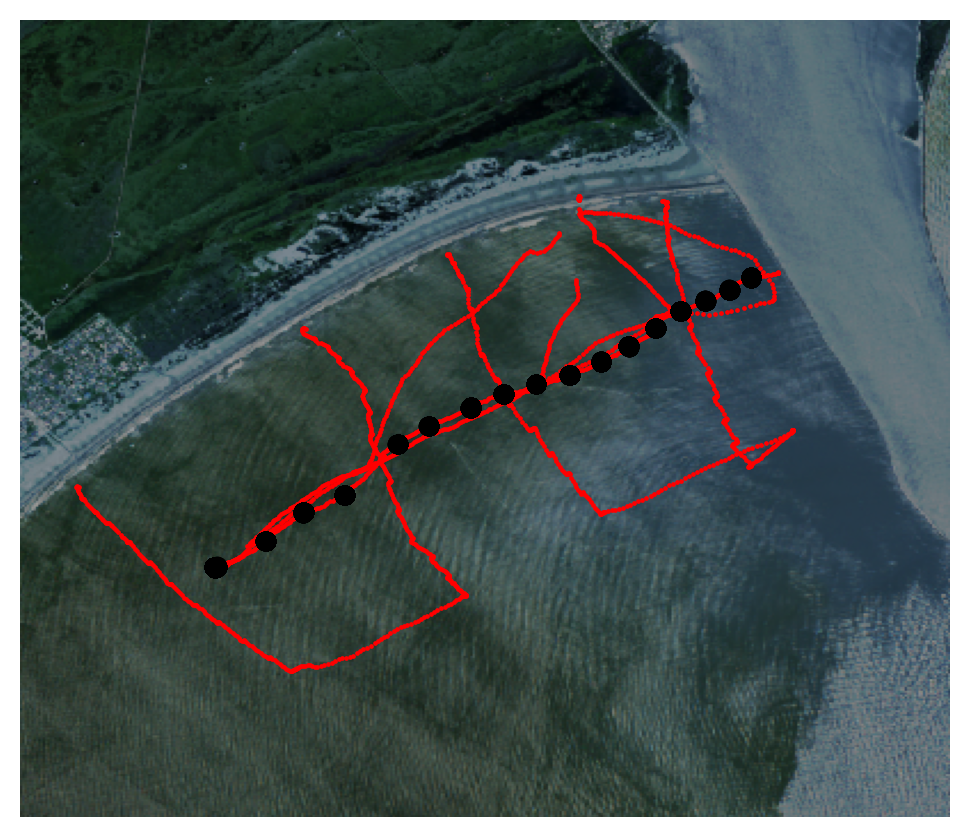

In [4]:
myProj = Proj('+proj=utm +zone=22 +south +datum=WGS84 +units=m +no_defs')

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

ax.imshow(rgb_img, extent=[img.bounds.left, img.bounds.right, img.bounds.bottom, img.bounds.top])
ax.scatter(data['dados_gps'][:][1], data['dados_gps'][:][2], s=0.5, color ='r')

for i in range(0,17):
    lon0 = np.interp(data['dados_ctd'][i][0][:], data['dados_gps'][0][:], data['dados_gps'][1][:])
    lat0 = np.interp(data['dados_ctd'][i][0][:], data['dados_gps'][0][:], data['dados_gps'][2][:])
    ax.scatter(lon0, lat0, color = 'k')

# Exibir a imagem rasterio
ax.set_xlim([-52.15, -52.08])
ax.set_ylim([-32.21, -32.15])
ax.axis('off')

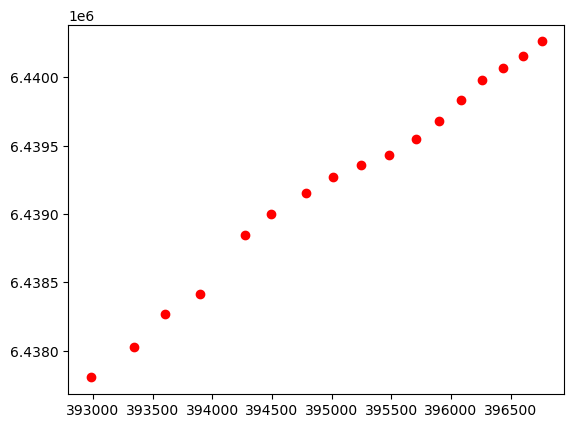

In [5]:
myProj = Proj('+proj=utm +zone=22 +south +datum=WGS84 +units=m +no_defs')
ctd_loc =  np.zeros((17, 15, 2))

for i in range(0,17):
    lon0 = np.interp(data['dados_ctd'][i][0][:], data['dados_gps'][0][:], data['dados_gps'][1][:])
    lat0 = np.interp(data['dados_ctd'][i][0][:], data['dados_gps'][0][:], data['dados_gps'][2][:])
    trashlon = np.mean(lon0)
    trashlat = np.mean(lat0)
    lon_,lat_ = myProj(trashlon, trashlat) 
    ctd_loc[i,0,0] = np.mean(lon_)
    ctd_loc[i,0,1] = np.mean(lat_)
    plt.scatter(ctd_loc[i,0,0], ctd_loc[i,0,1], color = 'r')
    
ctd_dist = np.sqrt((ctd_loc[1:,0,0] - ctd_loc[:-1,0,0])**2 + (ctd_loc[1:,0,1] - ctd_loc[:-1,0,1])**2)
ctd_cumdist = np.cumsum(ctd_dist)
ctd_cumdist = np.insert(ctd_cumdist, 0, 0)

In [6]:
z_norm = np.arange(0.3,8.55,0.05)
sal_norm = np.zeros((17,165))
turb_norm = np.zeros((17,165))
cla_norm = np.zeros((17,165))
od_norm = np.zeros((17,165))
temp_norm = np.zeros((17,165))
dens_norm = np.zeros((17,165))


In [7]:
print(np.shape(data['dados_ctd'][0][1][:219]), np.shape(np.flip(data['dados_ctd'][0][1][220:])))
teste = np.shape(data['dados_ctd'][0][1][:219]), np.shape(np.flip(data['dados_ctd'][0][1][220:]))

(219,) (288,)


219 8.025650545544883 140.0


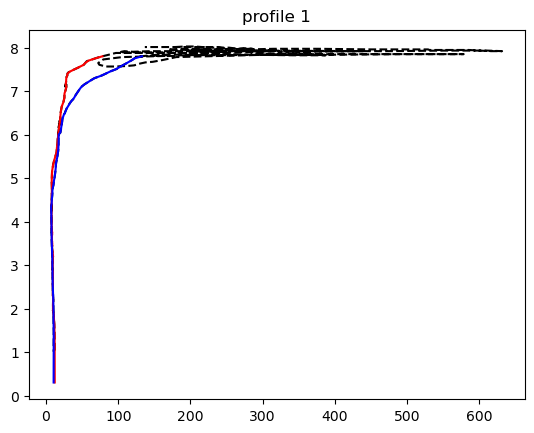

In [8]:
print(np.argmax(data['dados_ctd'][0][1][:]), np.max(data['dados_ctd'][0][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][0][1][:]),1))/0.05, 1))

plt.plot(data['dados_ctd'][0][5][:219], data['dados_ctd'][0][1][:219],'k', ls = '--')
plt.plot(data['dados_ctd'][0][5][220:], data['dados_ctd'][0][1][220:],'k', ls = '--')

trash1 = np.interp(z_norm, data['dados_ctd'][0][1][:219], data['dados_ctd'][0][3][:219])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][0][1][220:]), np.flip(data['dados_ctd'][0][3][220:]))
trash1[151:] = np.nan
trash2[151:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][0][1][:219], data['dados_ctd'][0][5][:219])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][0][1][220:]), np.flip(data['dados_ctd'][0][5][220:]))
trash3[151:] = np.nan
trash4[151:] = np.nan


trash5 = np.interp(z_norm, data['dados_ctd'][0][1][:219], data['dados_ctd'][0][4][:219])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][0][1][220:]), np.flip(data['dados_ctd'][0][4][220:]))
trash5[151:] = np.nan
trash6[151:] = np.nan


trash7 = np.interp(z_norm, data['dados_ctd'][0][1][:219], data['dados_ctd'][0][6][:219])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][0][1][220:]), np.flip(data['dados_ctd'][0][6][220:]))
trash7[151:] = np.nan
trash8[151:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][0][1][:219], data['dados_ctd'][0][2][:219])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][0][1][220:]), np.flip(data['dados_ctd'][0][2][220:]))
trash9[151:] = np.nan
trash10[151:] = np.nan


trash11 = np.interp(z_norm, data['dados_ctd'][0][1][:219], data['dados_ctd'][0][7][:219])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][0][1][220:]), np.flip(data['dados_ctd'][0][7][220:]))
trash11[151:] = np.nan
trash12[151:] = np.nan


plt.title('profile 1')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'b')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[0][:] = (trash1+trash2)/2
turb_norm[0][:] = (trash3+trash4)/2
cla_norm[0][:] = (trash5+trash6)/2
od_norm[0][:] = (trash7+trash8)/2
temp_norm[0][:] = (trash9+trash10)/2
dens_norm[0][:] = (trash11+trash12)/2

68 7.957627098354088 140.0


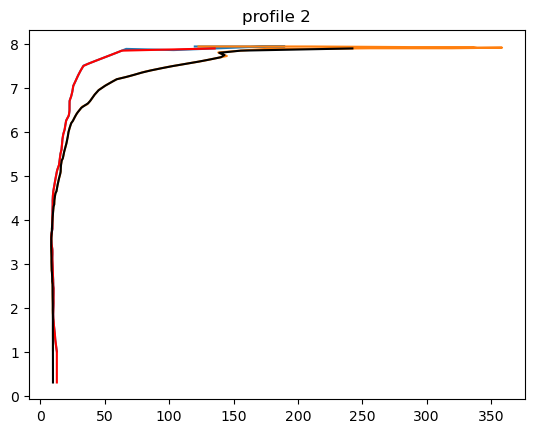

In [9]:
print(np.argmax(data['dados_ctd'][1][1][:]), np.max(data['dados_ctd'][1][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][1][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][1][5][:68], data['dados_ctd'][1][1][:68])
plt.plot(data['dados_ctd'][1][5][69:], data['dados_ctd'][1][1][69:])


trash1 = np.interp(z_norm, data['dados_ctd'][1][1][:68], data['dados_ctd'][1][3][:68])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][1][1][69:]), np.flip(data['dados_ctd'][1][3][69:]))
trash1[153:] = np.nan
trash2[153:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][1][1][:68], data['dados_ctd'][1][5][:68])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][1][1][69:]), np.flip(data['dados_ctd'][1][5][69:]))
trash3[153:] = np.nan
trash4[153:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][1][1][:68], data['dados_ctd'][1][4][:68])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][1][1][69:]), np.flip(data['dados_ctd'][1][4][69:]))
trash5[153:] = np.nan
trash6[153:] = np.nan


trash7 = np.interp(z_norm, data['dados_ctd'][1][1][:68], data['dados_ctd'][1][6][:68])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][1][1][69:]), np.flip(data['dados_ctd'][1][6][69:]))
trash7[153:] = np.nan
trash8[153:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][1][1][:68], data['dados_ctd'][1][2][:68])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][1][1][69:]), np.flip(data['dados_ctd'][1][2][69:]))
trash9[153:] = np.nan
trash10[153:] = np.nan


trash11 = np.interp(z_norm, data['dados_ctd'][1][1][:68], data['dados_ctd'][1][7][:68])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][1][1][69:]), np.flip(data['dados_ctd'][1][7][69:]))
trash11[153:] = np.nan
trash12[153:] = np.nan


plt.title('profile 2')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')



sal_norm[1][:] = trash1
turb_norm[1][:] = trash3
cla_norm[1][:] = trash5
od_norm[1][:] = trash7
temp_norm[1][:] = trash9
dens_norm[1][:] = trash11

93 8.364356762563268 148.0


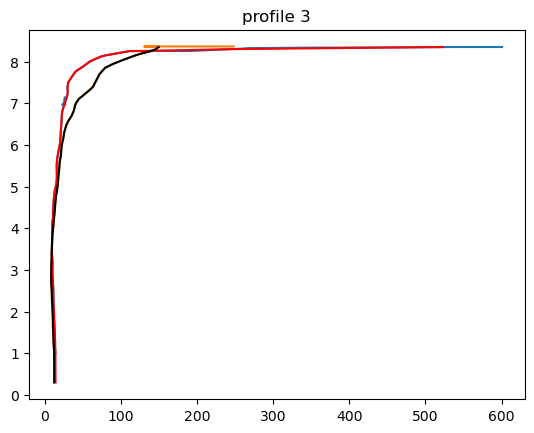

In [10]:
print(np.argmax(data['dados_ctd'][2][1][:]), np.max(data['dados_ctd'][2][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][2][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][2][5][:93], data['dados_ctd'][2][1][:93])
plt.plot(data['dados_ctd'][2][5][94:], data['dados_ctd'][2][1][94:])


trash1 = np.interp(z_norm, data['dados_ctd'][2][1][:93], data['dados_ctd'][2][3][:93])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][2][1][94:]), np.flip(data['dados_ctd'][2][3][94:]))
trash3 = np.interp(z_norm, data['dados_ctd'][2][1][:93], data['dados_ctd'][2][5][:93])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][2][1][94:]), np.flip(data['dados_ctd'][2][5][94:]))

trash5 = np.interp(z_norm, data['dados_ctd'][2][1][:93], data['dados_ctd'][2][4][:93])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][2][1][94:]), np.flip(data['dados_ctd'][2][4][94:]))

trash7 = np.interp(z_norm, data['dados_ctd'][2][1][:93], data['dados_ctd'][2][6][:93])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][2][1][94:]), np.flip(data['dados_ctd'][2][6][94:]))

trash9 = np.interp(z_norm, data['dados_ctd'][2][1][:93], data['dados_ctd'][2][2][:93])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][2][1][94:]), np.flip(data['dados_ctd'][2][2][94:]))

trash11 = np.interp(z_norm, data['dados_ctd'][2][1][:93], data['dados_ctd'][2][7][:93])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][2][1][94:]), np.flip(data['dados_ctd'][2][7][94:]))

trash1[162:] = np.nan
trash2[162:] = np.nan
trash3[162:] = np.nan
trash4[162:] = np.nan
trash5[162:] = np.nan
trash6[162:] = np.nan
trash7[162:] = np.nan
trash8[162:] = np.nan
trash9[162:] = np.nan
trash10[162:] = np.nan
trash11[162:] = np.nan
trash12[162:] = np.nan



plt.title('profile 3')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[2][:] = trash1
turb_norm[2][:] = trash3
cla_norm[2][:] = trash5
od_norm[2][:] = trash7
temp_norm[2][:] = trash9
dens_norm[2][:] = trash11

60 8.18860558967734 144.0


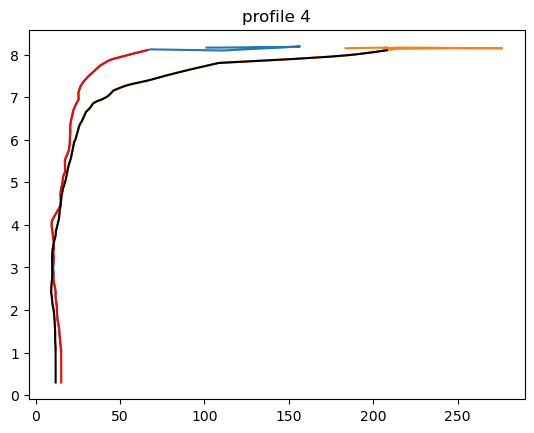

In [11]:
print(np.argmax(data['dados_ctd'][3][1][:]), np.max(data['dados_ctd'][3][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][3][1][:]),1))/0.05, 1))

plt.plot(data['dados_ctd'][3][5][:66], data['dados_ctd'][3][1][:66])
plt.plot(data['dados_ctd'][3][5][67:], data['dados_ctd'][3][1][67:])


trash1 = np.interp(z_norm, data['dados_ctd'][3][1][:66], data['dados_ctd'][3][3][:66])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][3][1][67:]), np.flip(data['dados_ctd'][3][3][67:]))
trash1[157:] = np.nan
trash2[157:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][3][1][:66], data['dados_ctd'][3][5][:66])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][3][1][67:]), np.flip(data['dados_ctd'][3][5][67:]))
trash3[157:] = np.nan
trash4[157:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][3][1][:66], data['dados_ctd'][3][4][:66])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][3][1][67:]), np.flip(data['dados_ctd'][3][4][67:]))
trash5[157:] = np.nan
trash6[157:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][3][1][:66], data['dados_ctd'][3][6][:66])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][3][1][67:]), np.flip(data['dados_ctd'][3][6][67:]))
trash7[157:] = np.nan
trash8[157:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][3][1][:66], data['dados_ctd'][3][2][:66])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][3][1][67:]), np.flip(data['dados_ctd'][3][2][67:]))
trash9[157:] = np.nan
trash10[157:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][3][1][:66], data['dados_ctd'][3][7][:66])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][3][1][67:]), np.flip(data['dados_ctd'][3][7][67:]))
trash11[157:] = np.nan
trash12[157:] = np.nan

plt.title('profile 4')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')


sal_norm[3][:] = trash1
turb_norm[3][:] = trash3
cla_norm[3][:] = trash5
od_norm[3][:] = trash7
temp_norm[3][:] = trash9
dens_norm[3][:] = trash11

57 7.957961965172079 140.0


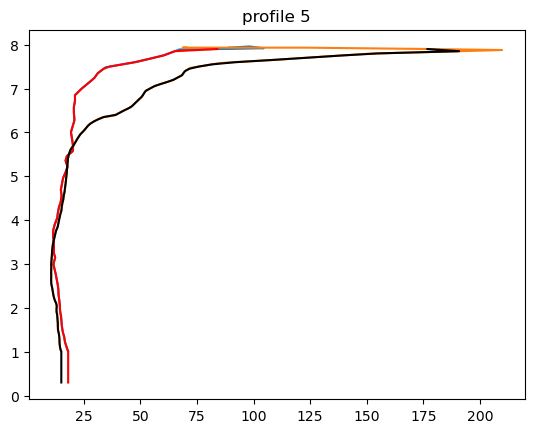

In [12]:
print(np.argmax(data['dados_ctd'][4][1][:]), np.max(data['dados_ctd'][4][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][4][1][:]),1))/0.05, 1))

plt.plot(data['dados_ctd'][4][5][:60], data['dados_ctd'][4][1][:60])
plt.plot(data['dados_ctd'][4][5][61:], data['dados_ctd'][4][1][61:])


trash1 = np.interp(z_norm, data['dados_ctd'][4][1][:60], data['dados_ctd'][4][3][:60])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][4][1][61:]), np.flip(data['dados_ctd'][4][3][61:]))
trash1[153:] = np.nan
trash2[153:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][4][1][:60], data['dados_ctd'][4][5][:60])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][4][1][61:]), np.flip(data['dados_ctd'][4][5][61:]))
trash3[153:] = np.nan
trash4[153:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][4][1][:60], data['dados_ctd'][4][4][:60])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][4][1][61:]), np.flip(data['dados_ctd'][4][4][61:]))
trash5[153:] = np.nan
trash6[153:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][4][1][:60], data['dados_ctd'][4][6][:60])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][4][1][61:]), np.flip(data['dados_ctd'][4][6][61:]))
trash7[153:] = np.nan
trash8[153:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][4][1][:60], data['dados_ctd'][4][2][:60])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][4][1][61:]), np.flip(data['dados_ctd'][4][2][61:]))
trash9[153:] = np.nan
trash10[153:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][4][1][:60], data['dados_ctd'][4][7][:60])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][4][1][61:]), np.flip(data['dados_ctd'][4][7][61:]))
trash11[153:] = np.nan
trash12[153:] = np.nan

plt.title('profile 5')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')


sal_norm[4][:] = trash1
turb_norm[4][:] = trash3
cla_norm[4][:] = trash5
od_norm[4][:] = trash7
temp_norm[4][:] = trash9
dens_norm[4][:] = trash11

61 7.646357382375103 132.0


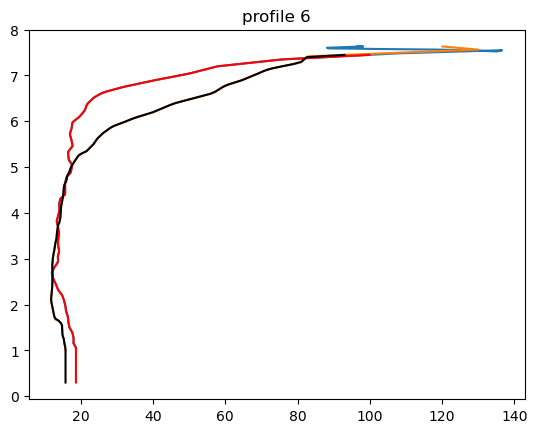

In [13]:
print(np.argmax(data['dados_ctd'][5][1][:]), np.max(data['dados_ctd'][5][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][5][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][5][5][:61], data['dados_ctd'][5][1][:61])
plt.plot(data['dados_ctd'][5][5][62:], data['dados_ctd'][5][1][62:])


trash1 = np.interp(z_norm, data['dados_ctd'][5][1][:61], data['dados_ctd'][5][3][:61])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][5][1][62:]), np.flip(data['dados_ctd'][5][3][62:]))
trash1[144:] = np.nan
trash2[144:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][5][1][:61], data['dados_ctd'][5][5][:61])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][5][1][62:]), np.flip(data['dados_ctd'][5][5][62:]))
trash3[144:] = np.nan
trash4[144:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][5][1][:61], data['dados_ctd'][5][4][:61])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][5][1][62:]), np.flip(data['dados_ctd'][5][4][62:]))
trash5[144:] = np.nan
trash6[144:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][5][1][:61], data['dados_ctd'][5][6][:61])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][5][1][62:]), np.flip(data['dados_ctd'][5][6][62:]))
trash7[144:] = np.nan
trash8[144:] = np.nan


trash9 = np.interp(z_norm, data['dados_ctd'][5][1][:61], data['dados_ctd'][5][2][:61])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][5][1][62:]), np.flip(data['dados_ctd'][5][2][62:]))
trash9[144:] = np.nan
trash10[144:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][5][1][:61], data['dados_ctd'][5][7][:61])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][5][1][62:]), np.flip(data['dados_ctd'][5][7][62:]))
trash11[144:] = np.nan
trash12[144:] = np.nan


plt.title('profile 6')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[5][:] = trash1
turb_norm[5][:] = trash3
cla_norm[5][:] = trash5
od_norm[5][:] = trash7
temp_norm[5][:] = trash9
dens_norm[5][:] = trash11

72 7.578535072309425 132.0


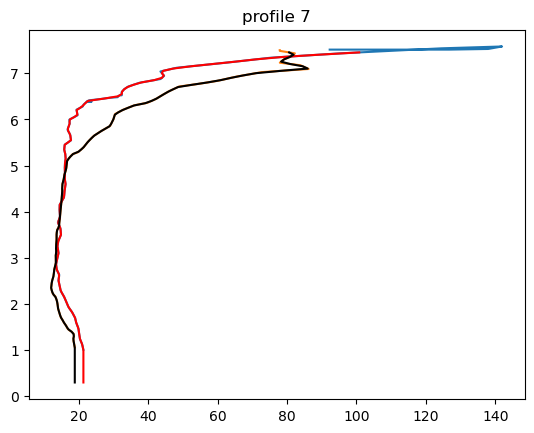

In [14]:
print(np.argmax(data['dados_ctd'][6][1][:]), np.max(data['dados_ctd'][6][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][6][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][6][5][:77], data['dados_ctd'][6][1][:77])
plt.plot(data['dados_ctd'][6][5][78:], data['dados_ctd'][6][1][78:])


trash1 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][3][:77])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][3][78:]))
trash1[144:] = np.nan
trash2[144:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][5][:77])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][5][78:]))
trash3[144:] = np.nan
trash4[144:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][4][:77])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][4][78:]))
trash5[144:] = np.nan
trash6[144:] = np.nan


trash7 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][6][:77])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][6][78:]))
trash7[144:] = np.nan
trash8[144:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][2][:77])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][2][78:]))
trash9[144:] = np.nan
trash10[144:] = np.nan


trash11 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][7][:77])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][7][78:]))
trash11[144:] = np.nan
trash12[144:] = np.nan


trash11 = np.interp(z_norm, data['dados_ctd'][6][1][:77], data['dados_ctd'][6][7][:77])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][6][1][78:]), np.flip(data['dados_ctd'][6][7][78:]))
trash11[140:] = np.nan
trash12[140:] = np.nan

plt.title('profile 7')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[6][:] = trash1
turb_norm[6][:] = trash3
cla_norm[6][:] = trash5
od_norm[6][:] = trash7
temp_norm[6][:] = trash9
dens_norm[6][:] = trash11

52 7.538569165533897 130.0


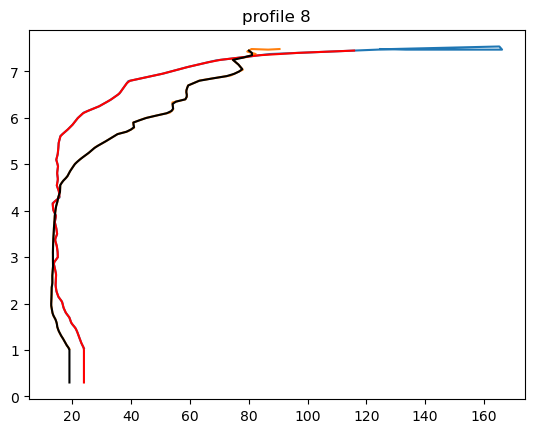

In [15]:
print(np.argmax(data['dados_ctd'][7][1][:]), np.max(data['dados_ctd'][7][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][7][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][7][5][:57], data['dados_ctd'][7][1][:57])
plt.plot(data['dados_ctd'][7][5][58:], data['dados_ctd'][7][1][58:])


trash1 = np.interp(z_norm, data['dados_ctd'][7][1][:57], data['dados_ctd'][7][3][:57])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][7][1][58:]), np.flip(data['dados_ctd'][7][3][58:]))
trash1[144:] = np.nan
trash2[144:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][7][1][:57], data['dados_ctd'][7][5][:57])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][7][1][58:]), np.flip(data['dados_ctd'][7][5][58:]))
trash3[144:] = np.nan
trash4[144:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][7][1][:57], data['dados_ctd'][7][4][:57])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][7][1][58:]), np.flip(data['dados_ctd'][7][4][58:]))
trash5[144:] = np.nan
trash6[144:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][7][1][:57], data['dados_ctd'][7][6][:57])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][7][1][58:]), np.flip(data['dados_ctd'][7][6][58:]))
trash7[144:] = np.nan
trash8[144:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][7][1][:57], data['dados_ctd'][7][2][:57])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][7][1][58:]), np.flip(data['dados_ctd'][7][2][58:]))
trash9[144:] = np.nan
trash10[144:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][7][1][:57], data['dados_ctd'][7][7][:57])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][7][1][58:]), np.flip(data['dados_ctd'][7][7][58:]))
trash11[144:] = np.nan
trash12[144:] = np.nan


plt.title('profile 8')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[7][:] = trash1
turb_norm[7][:] = trash3
cla_norm[7][:] = trash5
od_norm[7][:] = trash7
temp_norm[7][:] = trash9
dens_norm[7][:] = trash11

48 7.375881339677789 128.0


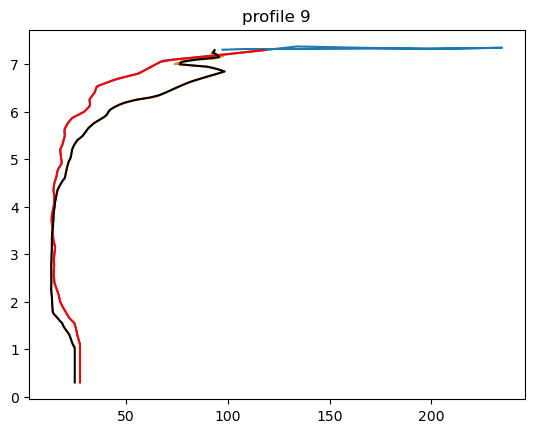

In [16]:
print(np.argmax(data['dados_ctd'][8][1][:]), np.max(data['dados_ctd'][8][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][8][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][8][5][:57], data['dados_ctd'][8][1][:57])
plt.plot(data['dados_ctd'][8][5][58:], data['dados_ctd'][8][1][58:])


trash1 = np.interp(z_norm, data['dados_ctd'][8][1][:57], data['dados_ctd'][8][3][:57])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][8][1][58:]), np.flip(data['dados_ctd'][8][3][58:]))
trash1[141:] = np.nan
trash2[141:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][8][1][:57], data['dados_ctd'][8][5][:57])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][8][1][58:]), np.flip(data['dados_ctd'][8][5][58:]))
trash3[141:] = np.nan
trash4[141:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][8][1][:57], data['dados_ctd'][8][4][:57])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][8][1][58:]), np.flip(data['dados_ctd'][8][4][58:]))
trash5[141:] = np.nan
trash6[141:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][8][1][:57], data['dados_ctd'][8][6][:57])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][8][1][58:]), np.flip(data['dados_ctd'][8][6][58:]))
trash7[141:] = np.nan
trash8[141:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][8][1][:57], data['dados_ctd'][8][2][:57])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][8][1][58:]), np.flip(data['dados_ctd'][8][2][58:]))
trash9[141:] = np.nan
trash10[141:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][8][1][:57], data['dados_ctd'][8][7][:57])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][8][1][58:]), np.flip(data['dados_ctd'][8][7][58:]))
trash11[141:] = np.nan
trash12[141:] = np.nan

plt.title('profile 9')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[8][:] = trash1
turb_norm[8][:] = trash3
cla_norm[8][:] = trash5
od_norm[8][:] = trash7
temp_norm[8][:] = trash9
dens_norm[8][:] = trash11

50 7.30803068188585 126.0


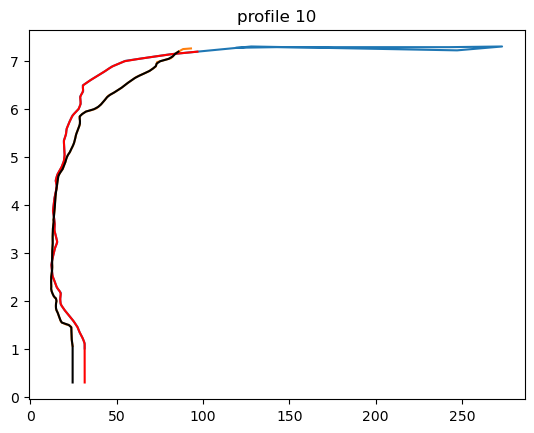

In [17]:
print(np.argmax(data['dados_ctd'][9][1][:]), np.max(data['dados_ctd'][9][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][9][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][9][5][:58], data['dados_ctd'][9][1][:58])
plt.plot(data['dados_ctd'][9][5][59:], data['dados_ctd'][9][1][59:])


trash1 = np.interp(z_norm, data['dados_ctd'][9][1][:58], data['dados_ctd'][9][3][:58])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][9][1][59:]), np.flip(data['dados_ctd'][9][3][59:]))
trash1[139:] = np.nan
trash2[139:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][9][1][:58], data['dados_ctd'][9][5][:58])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][9][1][59:]), np.flip(data['dados_ctd'][9][5][59:]))
trash3[139:] = np.nan
trash4[139:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][9][1][:58], data['dados_ctd'][9][4][:58])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][9][1][59:]), np.flip(data['dados_ctd'][9][4][59:]))
trash5[139:] = np.nan
trash6[139:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][9][1][:58], data['dados_ctd'][9][6][:58])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][9][1][59:]), np.flip(data['dados_ctd'][9][6][59:]))
trash7[139:] = np.nan
trash8[139:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][9][1][:58], data['dados_ctd'][9][2][:58])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][9][1][59:]), np.flip(data['dados_ctd'][9][2][59:]))
trash9[139:] = np.nan
trash10[139:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][9][1][:58], data['dados_ctd'][9][7][:58])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][9][1][59:]), np.flip(data['dados_ctd'][9][7][59:]))
trash11[139:] = np.nan
trash12[139:] = np.nan

plt.title('profile 10')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[9][:] = trash1
turb_norm[9][:] = trash3
cla_norm[9][:] = trash5
od_norm[9][:] = trash7
temp_norm[9][:] = trash9
dens_norm[9][:] = trash11

57 7.335037361038878 126.0


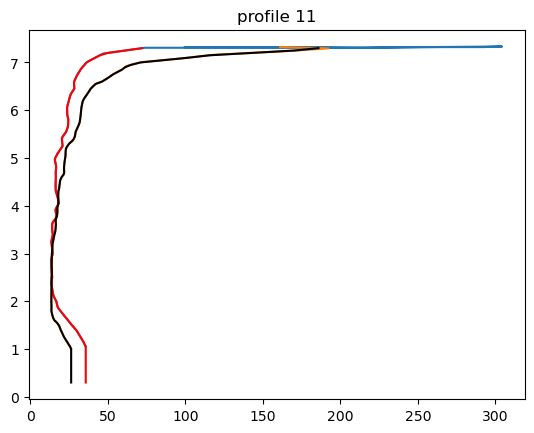

In [18]:
print(np.argmax(data['dados_ctd'][10][1][:]), np.max(data['dados_ctd'][10][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][10][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][10][5][:57], data['dados_ctd'][10][1][:57])
plt.plot(data['dados_ctd'][10][5][58:], data['dados_ctd'][10][1][58:])


trash1 = np.interp(z_norm, data['dados_ctd'][10][1][:57], data['dados_ctd'][10][3][:57])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][10][1][58:]), np.flip(data['dados_ctd'][10][3][58:]))
trash1[141:] = np.nan
trash2[141:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][10][1][:57], data['dados_ctd'][10][5][:57])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][10][1][58:]), np.flip(data['dados_ctd'][10][5][58:]))
trash3[141:] = np.nan
trash4[141:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][10][1][:57], data['dados_ctd'][10][4][:57])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][10][1][58:]), np.flip(data['dados_ctd'][10][4][58:]))
trash5[141:] = np.nan
trash6[141:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][10][1][:57], data['dados_ctd'][10][6][:57])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][10][1][58:]), np.flip(data['dados_ctd'][10][6][58:]))
trash7[141:] = np.nan
trash8[141:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][10][1][:57], data['dados_ctd'][10][2][:57])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][10][1][58:]), np.flip(data['dados_ctd'][10][2][58:]))
trash9[141:] = np.nan
trash10[141:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][10][1][:57], data['dados_ctd'][10][7][:57])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][10][1][58:]), np.flip(data['dados_ctd'][10][7][58:]))
trash11[141:] = np.nan
trash12[141:] = np.nan

plt.title('profile 11')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[10][:] = trash1
turb_norm[10][:] = trash3
cla_norm[10][:] = trash5
od_norm[10][:] = trash7
temp_norm[10][:] = trash9
dens_norm[10][:] = trash11

53 7.307320905243441 126.0


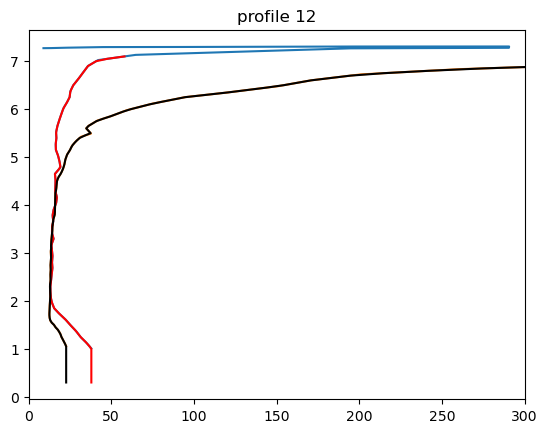

In [19]:
print(np.argmax(data['dados_ctd'][11][1][:]), np.max(data['dados_ctd'][11][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][11][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][11][5][:60], data['dados_ctd'][11][1][:60])
plt.plot(data['dados_ctd'][11][5][71:], data['dados_ctd'][11][1][71:])


trash1 = np.interp(z_norm, data['dados_ctd'][11][1][:60], data['dados_ctd'][11][3][:60])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][11][1][71:]), np.flip(data['dados_ctd'][11][3][71:]))
trash1[137:] = np.nan
trash2[137:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][11][1][:60], data['dados_ctd'][11][5][:60])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][11][1][71:]), np.flip(data['dados_ctd'][11][5][71:]))
trash3[137:] = np.nan
trash4[137:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][11][1][:60], data['dados_ctd'][11][4][:60])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][11][1][71:]), np.flip(data['dados_ctd'][11][4][71:]))
trash5[137:] = np.nan
trash6[137:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][11][1][:60], data['dados_ctd'][11][6][:60])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][11][1][71:]), np.flip(data['dados_ctd'][11][6][71:]))
trash7[137:] = np.nan
trash8[137:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][11][1][:60], data['dados_ctd'][11][2][:60])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][11][1][71:]), np.flip(data['dados_ctd'][11][2][71:]))
trash9[137:] = np.nan
trash10[137:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][11][1][:60], data['dados_ctd'][11][7][:60])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][11][1][71:]), np.flip(data['dados_ctd'][11][7][71:]))
trash11[137:] = np.nan
trash12[137:] = np.nan


plt.title('profile 12')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')
plt.xlim([0,300])

sal_norm[11][:] = trash1
turb_norm[11][:] = trash3
cla_norm[11][:] = trash5
od_norm[11][:] = trash7
temp_norm[11][:] = trash9
dens_norm[11][:] = trash11

50 7.206207987625618 124.0


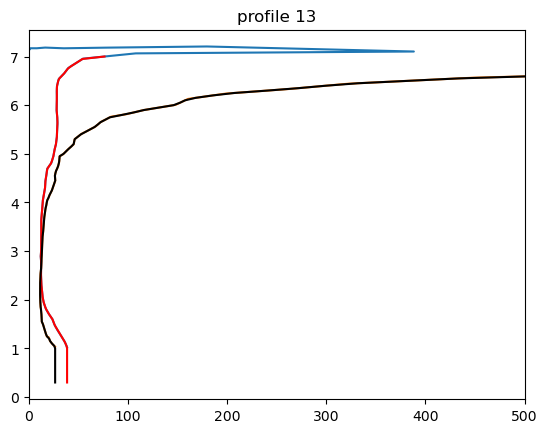

In [20]:
print(np.argmax(data['dados_ctd'][12][1][:]), np.max(data['dados_ctd'][12][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][12][1][:]),1))/0.05, 1))

plt.plot(data['dados_ctd'][12][5][:59], data['dados_ctd'][12][1][:59])
plt.plot(data['dados_ctd'][12][5][65:], data['dados_ctd'][12][1][65:])


trash1 = np.interp(z_norm, data['dados_ctd'][12][1][:59], data['dados_ctd'][12][3][:59])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][12][1][65:]), np.flip(data['dados_ctd'][12][3][65:]))
trash1[135:] = np.nan
trash2[135:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][12][1][:59], data['dados_ctd'][12][5][:59])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][12][1][65:]), np.flip(data['dados_ctd'][12][5][65:]))
trash3[135:] = np.nan
trash4[135:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][12][1][:59], data['dados_ctd'][12][4][:59])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][12][1][65:]), np.flip(data['dados_ctd'][12][4][65:]))
trash5[135:] = np.nan
trash6[135:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][12][1][:59], data['dados_ctd'][12][6][:59])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][12][1][65:]), np.flip(data['dados_ctd'][12][6][65:]))
trash7[135:] = np.nan
trash8[135:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][12][1][:59], data['dados_ctd'][12][2][:59])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][12][1][65:]), np.flip(data['dados_ctd'][12][2][65:]))
trash9[135:] = np.nan
trash10[135:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][12][1][:59], data['dados_ctd'][12][7][:59])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][12][1][65:]), np.flip(data['dados_ctd'][12][7][65:]))
trash11[135:] = np.nan
trash12[135:] = np.nan


plt.title('profile 13')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')
plt.xlim([0,500])


sal_norm[12][:] = trash1
turb_norm[12][:] = trash3
cla_norm[12][:] = trash5
od_norm[12][:] = trash7
temp_norm[12][:] = trash9
dens_norm[12][:] = trash11

56 6.864875073961947 118.0


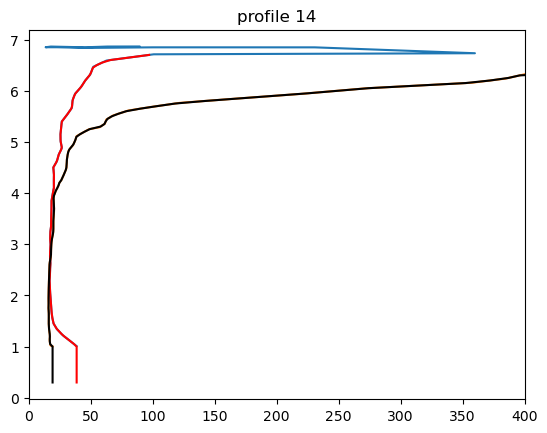

In [21]:
print(np.argmax(data['dados_ctd'][13][1][:]), np.max(data['dados_ctd'][13][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][13][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][13][5][:57], data['dados_ctd'][13][1][:57])
plt.plot(data['dados_ctd'][13][5][60:], data['dados_ctd'][13][1][60:])


trash1 = np.interp(z_norm, data['dados_ctd'][13][1][:57], data['dados_ctd'][13][3][:57])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][13][1][60:]), np.flip(data['dados_ctd'][13][3][60:]))
trash1[129:] = np.nan
trash2[129:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][13][1][:57], data['dados_ctd'][13][5][:57])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][13][1][60:]), np.flip(data['dados_ctd'][13][5][60:]))
trash3[129:] = np.nan
trash4[129:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][13][1][:57], data['dados_ctd'][13][4][:57])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][13][1][60:]), np.flip(data['dados_ctd'][13][4][60:]))
trash5[129:] = np.nan
trash6[129:] = np.nan


trash7 = np.interp(z_norm, data['dados_ctd'][13][1][:57], data['dados_ctd'][13][6][:57])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][13][1][60:]), np.flip(data['dados_ctd'][13][6][60:]))
trash7[129:] = np.nan
trash8[129:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][13][1][:57], data['dados_ctd'][13][2][:57])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][13][1][60:]), np.flip(data['dados_ctd'][13][2][60:]))
trash9[129:] = np.nan
trash10[129:] = np.nan


trash11 = np.interp(z_norm, data['dados_ctd'][13][1][:57], data['dados_ctd'][13][7][:57])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][13][1][60:]), np.flip(data['dados_ctd'][13][7][60:]))
trash11[129:] = np.nan
trash12[129:] = np.nan


plt.title('profile 14')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')
plt.xlim([0,400])


sal_norm[13][:] = trash1
turb_norm[13][:] = trash3
cla_norm[13][:] = trash5
od_norm[13][:] = trash7
temp_norm[13][:] = trash9
dens_norm[13][:] = trash11

50 6.359173223488498 108.0


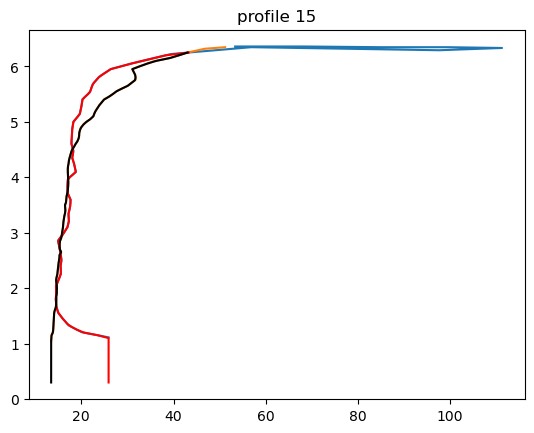

In [22]:
print(np.argmax(data['dados_ctd'][14][1][:]), np.max(data['dados_ctd'][14][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][14][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][14][5][:50], data['dados_ctd'][14][1][:50])
plt.plot(data['dados_ctd'][14][5][51:], data['dados_ctd'][14][1][51:])


trash1 = np.interp(z_norm, data['dados_ctd'][14][1][:50], data['dados_ctd'][14][3][:50])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][14][1][51:]), np.flip(data['dados_ctd'][14][3][51:]))
trash1[120:] = np.nan
trash2[120:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][14][1][:50], data['dados_ctd'][14][5][:50])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][14][1][51:]), np.flip(data['dados_ctd'][14][5][51:]))
trash3[120:] = np.nan
trash4[120:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][14][1][:50], data['dados_ctd'][14][4][:50])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][14][1][51:]), np.flip(data['dados_ctd'][14][4][51:]))
trash5[120:] = np.nan
trash6[120:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][14][1][:50], data['dados_ctd'][14][6][:50])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][14][1][51:]), np.flip(data['dados_ctd'][14][6][51:]))
trash7[120:] = np.nan
trash8[120:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][14][1][:50], data['dados_ctd'][14][2][:50])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][14][1][51:]), np.flip(data['dados_ctd'][14][2][51:]))
trash9[120:] = np.nan
trash10[120:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][14][1][:50], data['dados_ctd'][14][7][:50])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][14][1][51:]), np.flip(data['dados_ctd'][14][7][51:]))
trash11[120:] = np.nan
trash12[120:] = np.nan

plt.title('profile 15')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[14][:] = trash1
turb_norm[14][:] = trash3
cla_norm[14][:] = trash5
od_norm[14][:] = trash7
temp_norm[14][:] = trash9
dens_norm[14][:] = trash11

47 5.748760422461947 94.0


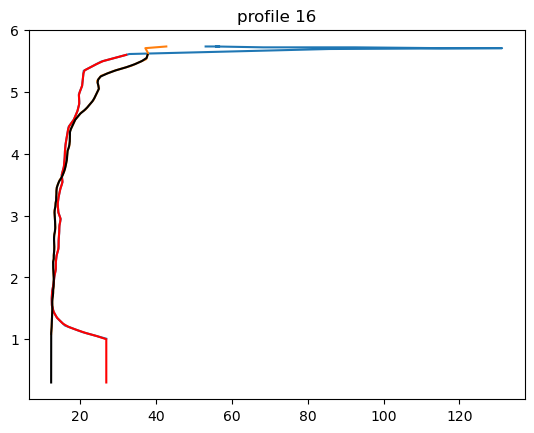

In [23]:
print(np.argmax(data['dados_ctd'][15][1][:]), np.max(data['dados_ctd'][15][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][15][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][15][5][:47], data['dados_ctd'][15][1][:47])
plt.plot(data['dados_ctd'][15][5][48:], data['dados_ctd'][15][1][48:])


trash1 = np.interp(z_norm, data['dados_ctd'][15][1][:47], data['dados_ctd'][15][3][:47])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][15][1][48:]), np.flip(data['dados_ctd'][15][3][48:]))
trash1[107:] = np.nan
trash2[107:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][15][1][:47], data['dados_ctd'][15][5][:47])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][15][1][48:]), np.flip(data['dados_ctd'][15][5][48:]))
trash3[107:] = np.nan
trash4[107:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][15][1][:47], data['dados_ctd'][15][4][:47])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][15][1][48:]), np.flip(data['dados_ctd'][15][4][48:]))
trash5[107:] = np.nan
trash6[107:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][15][1][:47], data['dados_ctd'][15][6][:47])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][15][1][48:]), np.flip(data['dados_ctd'][15][6][48:]))
trash7[107:] = np.nan
trash8[107:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][15][1][:47], data['dados_ctd'][15][2][:47])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][15][1][48:]), np.flip(data['dados_ctd'][15][2][48:]))
trash9[107:] = np.nan
trash10[107:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][15][1][:47], data['dados_ctd'][15][7][:47])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][15][1][48:]), np.flip(data['dados_ctd'][15][7][48:]))
trash11[107:] = np.nan
trash12[107:] = np.nan

plt.title('profile 16')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[15][:] = trash1
turb_norm[15][:] = trash3
cla_norm[15][:] = trash5
od_norm[15][:] = trash7
temp_norm[15][:] = trash9
dens_norm[15][:] = trash11

34 4.935500378103715 78.0


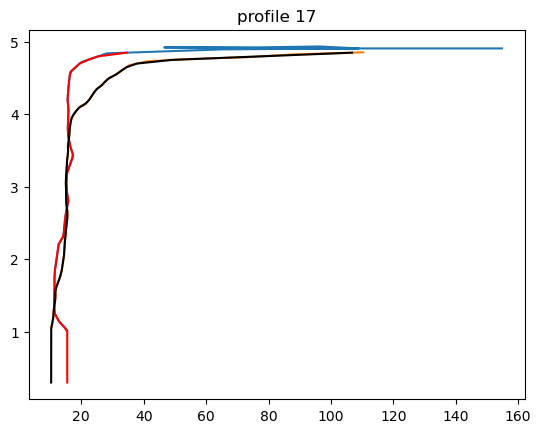

In [24]:
print(np.argmax(data['dados_ctd'][16][1][:]), np.max(data['dados_ctd'][16][1][:]),
      148 - np.round((8.4-np.round(np.max(data['dados_ctd'][16][1][:]),1))/0.05, 1))


plt.plot(data['dados_ctd'][16][5][:41], data['dados_ctd'][16][1][:41])
plt.plot(data['dados_ctd'][16][5][42:], data['dados_ctd'][16][1][42:])


trash1 = np.interp(z_norm, data['dados_ctd'][16][1][:41], data['dados_ctd'][16][3][:41])
trash2 = np.interp(z_norm, np.flip(data['dados_ctd'][16][1][42:]), np.flip(data['dados_ctd'][16][3][42:]))
trash1[92:] = np.nan
trash2[92:] = np.nan
trash3 = np.interp(z_norm, data['dados_ctd'][16][1][:41], data['dados_ctd'][16][5][:41])
trash4 = np.interp(z_norm, np.flip(data['dados_ctd'][16][1][42:]), np.flip(data['dados_ctd'][16][5][42:]))
trash3[92:] = np.nan
trash4[92:] = np.nan

trash5 = np.interp(z_norm, data['dados_ctd'][16][1][:41], data['dados_ctd'][16][4][:41])
trash6 = np.interp(z_norm, np.flip(data['dados_ctd'][16][1][42:]), np.flip(data['dados_ctd'][16][4][42:]))
trash5[92:] = np.nan
trash6[92:] = np.nan

trash7 = np.interp(z_norm, data['dados_ctd'][16][1][:41], data['dados_ctd'][16][6][:41])
trash8 = np.interp(z_norm, np.flip(data['dados_ctd'][16][1][42:]), np.flip(data['dados_ctd'][16][6][42:]))
trash7[92:] = np.nan
trash8[92:] = np.nan

trash9 = np.interp(z_norm, data['dados_ctd'][16][1][:41], data['dados_ctd'][16][2][:41])
trash10 = np.interp(z_norm, np.flip(data['dados_ctd'][16][1][42:]), np.flip(data['dados_ctd'][16][2][42:]))
trash9[92:] = np.nan
trash10[92:] = np.nan

trash11 = np.interp(z_norm, data['dados_ctd'][16][1][:41], data['dados_ctd'][16][7][:41])
trash12 = np.interp(z_norm, np.flip(data['dados_ctd'][16][1][42:]), np.flip(data['dados_ctd'][16][7][42:]))
trash11[92:] = np.nan
trash12[92:] = np.nan


plt.title('profile 17')
plt.plot(trash3,z_norm, 'r')
plt.plot(trash4,z_norm, 'k')
#plt.plot((trash1+trash2)/2,z_norm, 'b')

sal_norm[16][:] = trash1
turb_norm[16][:] = trash3
cla_norm[16][:] = trash5
od_norm[16][:] = trash7
temp_norm[16][:] = trash9
dens_norm[16][:] = trash11

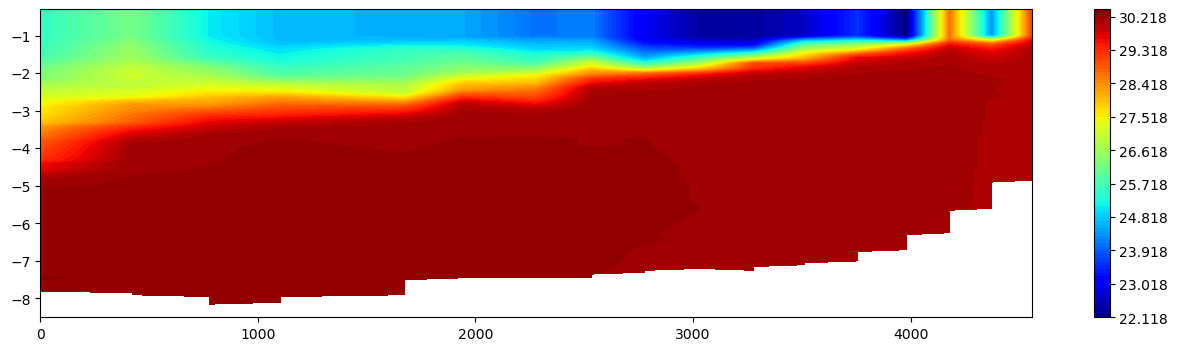

In [25]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, sal_norm.T, np.arange(np.nanmin(sal_norm),np.nanmax(sal_norm)+0.1,0.1), cmap=plt.cm.jet)
plt.colorbar(q)

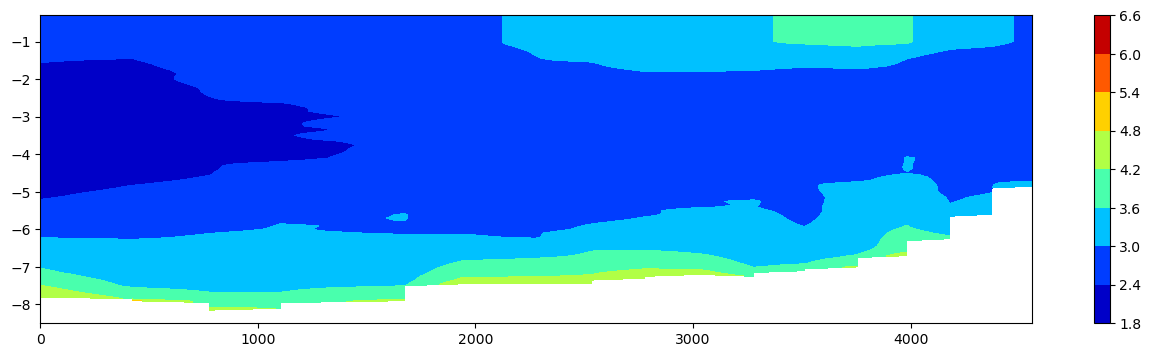

In [26]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(turb_norm.T),  cmap=plt.cm.jet)
plt.colorbar(q)

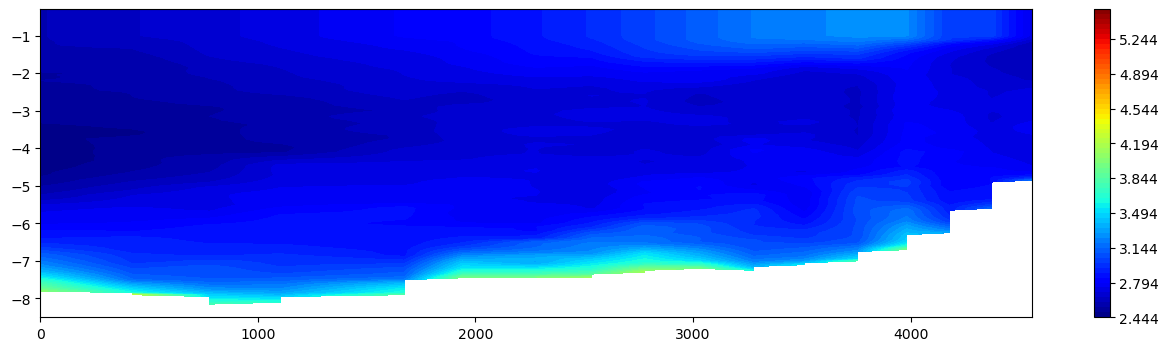

In [27]:
ssc = 8.215 + 0.455*turb_norm#-1.05+1.03*turb_norm

fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(ssc.T), np.arange(np.nanmin(np.log(ssc.T)),np.nanmax(np.log(ssc.T))+0.05,0.05),  cmap=plt.cm.jet)
plt.colorbar(q)

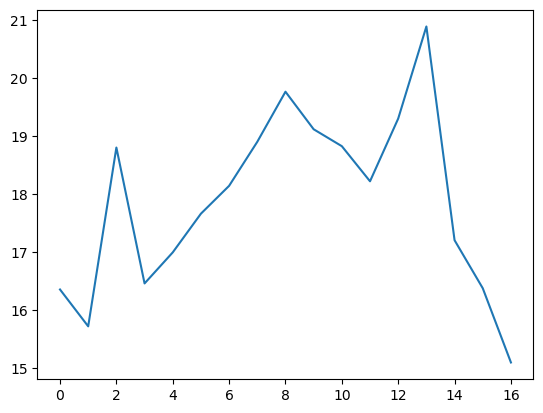

In [28]:
plt.plot(np.nanmean(ssc,1))

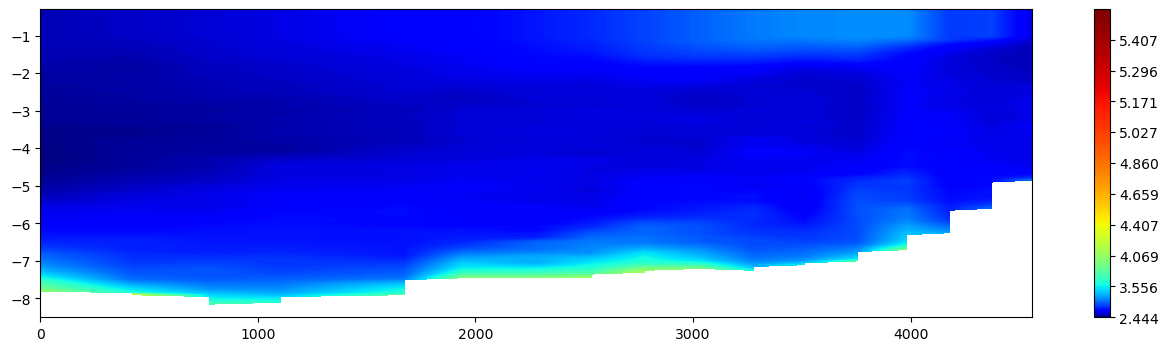

In [29]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(ssc.T), np.log(np.arange(np.nanmin(ssc),np.nanmax(ssc)+0.1,0.1)),  cmap=plt.cm.jet)
plt.colorbar(q)

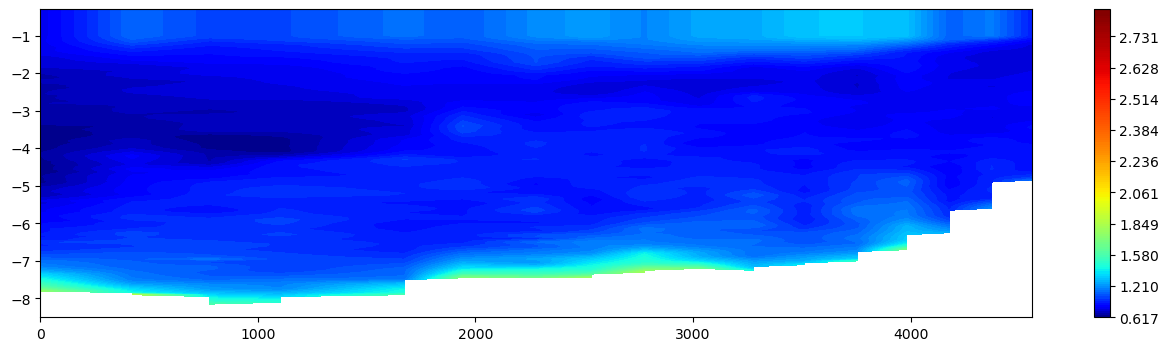

In [30]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(cla_norm.T), np.log(np.arange(np.nanmin(cla_norm),np.nanmax(cla_norm)+0.1,0.1)),  cmap=plt.cm.jet)
plt.colorbar(q)

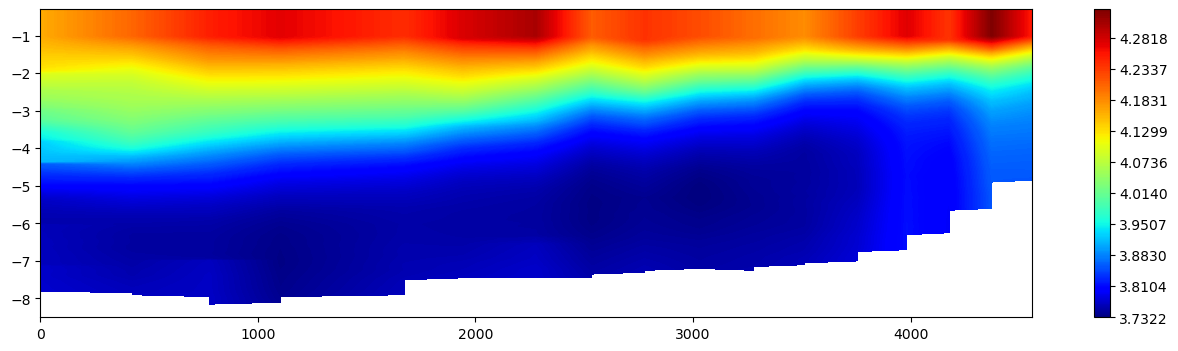

In [31]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, np.log(od_norm.T), np.log(np.arange(np.nanmin(od_norm),np.nanmax(od_norm)+0.1,0.1)),  cmap=plt.cm.jet)
plt.colorbar(q)

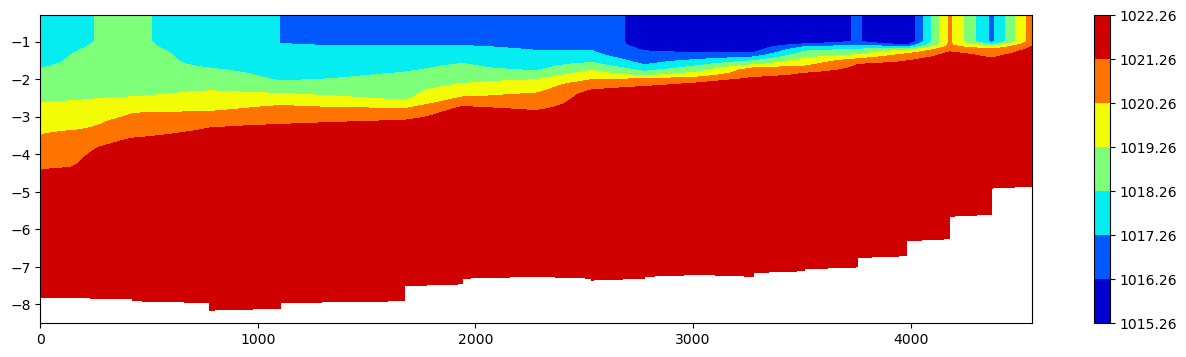

In [32]:
fig, ax = plt.subplots(figsize=(16,4), dpi = 100)

q = ax.contourf(ctd_cumdist, -z_norm, (dens_norm.T), (np.arange(np.nanmin(dens_norm),np.nanmax(dens_norm)+1,1)),  cmap=plt.cm.jet)
plt.colorbar(q)

In [33]:
dados_ctd1 = np.zeros((10,165,17))
dados_ctd1[0] = sal_norm.T
dados_ctd1[1] = turb_norm.T
dados_ctd1[2] = ssc.T
dados_ctd1[3] = cla_norm.T
dados_ctd1[4] = od_norm.T
dados_ctd1[5] = temp_norm.T
dados_ctd1[6] = dens_norm.T
dados_ctd1[7] = ctd_cumdist
dados_ctd1[8] = ctd_loc[:,0,0]
dados_ctd1[9] = ctd_loc[:,0,1]


with open('C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\CTD1_REV.pkl', 'wb') as file:
    pickle.dump(dados_ctd1, file)

In [34]:
ctd_loc[:,0,0]

array([392984.51346246, 393341.46596169, 393605.56427866, 393894.87402276,
       394270.7981116 , 394488.71463917, 394785.21427906, 395014.62459778,
       395244.21263241, 395483.07363281, 395704.23725153, 395899.4515704 ,
       396085.95479337, 396262.5825471 , 396436.57742984, 396607.6614353 ,
       396762.44160791])